# 🧠 Notebook 03 — LSTM Signal Model
**Stacked LSTM → 3-class signal predictor (Buy / Sell / Hold)**


In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import pickle, yaml, os, time
from pathlib import Path
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from tqdm import tqdm

BASE_DIR = Path('.')
DATA_PROC = BASE_DIR / 'data' / 'processed'
MODEL_DIR = BASE_DIR / 'models' / 'lstm_checkpoints'
MODEL_DIR.mkdir(parents=True, exist_ok=True)

with open(BASE_DIR / 'configs' / 'model_config.yaml') as f:
    cfg = yaml.safe_load(f)['lstm']

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'Config: hidden={cfg["hidden_size"]}, layers={cfg["num_layers"]}, lr={cfg["learning_rate"]}')

Device: cuda
Config: hidden=256, layers=4, lr=0.001


## 1. Dataset Loader

In [2]:
class OHLCVDataset(Dataset):
    """PyTorch Dataset wrapping (N, seq_len, features) arrays."""
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

# Load first available symbol for demonstration (SPY preferred)
pkl_files = sorted(DATA_PROC.glob('*.pkl'))
assert len(pkl_files) > 0, 'Run 02_data_pipeline.ipynb first!'

# Try to use SPY, fallback to first available
target_file = next((f for f in pkl_files if 'SPY' in f.name), pkl_files[0])
print(f'Loading: {target_file.name}')

with open(target_file, 'rb') as f:
    data = pickle.load(f)

X_train, y_train = data['X_train'], data['y_train']
X_val,   y_val   = data['X_val'],   data['y_val']
X_test,  y_test  = data['X_test'],  data['y_test']

N_FEATURES = X_train.shape[2]
SEQ_LEN    = X_train.shape[1]

print(f'Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}')
print(f'Features: {N_FEATURES}, Sequence: {SEQ_LEN}')
print(f'Label counts (train): {Counter(y_train)}')

# ---- Balanced sampler for imbalanced classes ----
class_counts = np.bincount(y_train)
class_weights = 1.0 / class_counts
sample_weights = class_weights[y_train]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

BATCH_SIZE = cfg['batch_size']
train_ds = OHLCVDataset(X_train, y_train)
val_ds   = OHLCVDataset(X_val,   y_val)
test_ds  = OHLCVDataset(X_test,  y_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

Loading: SPY_processed.pkl
Train: (5277, 60, 32), Val: (192, 60, 32), Test: (1045, 60, 32)
Features: 32, Sequence: 60
Label counts (train): Counter({np.int64(1): 2464, np.int64(2): 1631, np.int64(0): 1182})


## 2. LSTM Model Architecture

In [3]:
class LSTMTradingModel(nn.Module):
    """
    Stacked LSTM → LayerNorm → FC → Softmax
    Input:  (batch, seq_len, n_features)
    Output: (batch, 3)  — logits for Hold / Buy / Sell
    """
    def __init__(self, input_size: int, hidden_size: int, num_layers: int,
                 output_size: int = 3, dropout: float = 0.25):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers
        
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=False
        )
        self.layer_norm = nn.LayerNorm(hidden_size)
        self.fc1    = nn.Linear(hidden_size, 64)
        self.relu   = nn.ReLU()
        self.drop   = nn.Dropout(0.30)
        self.fc2    = nn.Linear(64, output_size)
    
    def forward(self, x):
        # x: (batch, seq, features)
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        
        out, _ = self.lstm(x, (h0, c0))
        out = out[:, -1, :]         # Take last timestep output
        out = self.layer_norm(out)
        out = self.drop(self.relu(self.fc1(out)))
        return self.fc2(out)        # Raw logits

model = LSTMTradingModel(
    input_size  = N_FEATURES,
    hidden_size = cfg['hidden_size'],
    num_layers  = cfg['num_layers'],
    output_size = cfg['output_size'],
    dropout     = cfg['dropout']
).to(device)


total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'\n🔢 Total trainable parameters: {total_params:,}')

LSTMTradingModel(
  (lstm): LSTM(32, 256, num_layers=4, batch_first=True, dropout=0.2)
  (layer_norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True, bias=True)
  (fc1): Linear(in_features=256, out_features=64, bias=True)
  (relu): ReLU()
  (drop): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=64, out_features=3, bias=True)
)

🔢 Total trainable parameters: 1,893,123


## 3. Training Loop

In [4]:
# ---- Loss: Standard CrossEntropy (sampler handles class balance) ----
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(),
                        lr=cfg['learning_rate'],
                        weight_decay=cfg['weight_decay'])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',
                                                  patience=7, factor=0.5)

EPOCHS   = cfg['epochs']
PATIENCE = cfg['patience']

train_losses, val_losses, val_f1s = [], [], []
best_val_loss = float('inf')
patience_counter = 0
best_epoch = 0

print(f'🚀 Training LSTM for {EPOCHS} epochs (patience={PATIENCE})')
print('=' * 65)

for epoch in range(1, EPOCHS + 1):
    # ---- Train ----
    model.train()
    train_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)
    
    # ---- Validation ----
    model.eval()
    val_loss, all_preds, all_labels = 0.0, [], []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = model(X_batch)
            val_loss += criterion(logits, y_batch).item()
            preds = logits.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y_batch.cpu().numpy())
    val_loss /= len(val_loader)
    val_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_f1s.append(val_f1)
    scheduler.step(val_loss)
    
    # ---- Early Stopping & Checkpoint ----
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_epoch = epoch
        torch.save({'epoch': epoch, 'model_state': model.state_dict(),
                    'optimizer_state': optimizer.state_dict(), 'val_loss': val_loss},
                   MODEL_DIR / 'best_lstm.pth')
        marker = ' ← best'
    else:
        patience_counter += 1
        marker = ''
    
    if epoch % 5 == 0 or epoch == 1:
        lr = optimizer.param_groups[0]['lr']
        print(f'Epoch {epoch:3d}/{EPOCHS} | train={train_loss:.4f} | val={val_loss:.4f} | '
              f'F1={val_f1:.3f} | lr={lr:.6f}{marker}')
    
    if patience_counter >= PATIENCE:
        print(f'\n⏹️  Early stopping at epoch {epoch} (best={best_epoch})')
        break

print(f'\n✅ Best model: epoch {best_epoch}, val_loss={best_val_loss:.4f}')

🚀 Training LSTM for 100 epochs (patience=15)
Epoch   1/100 | train=1.0992 | val=1.0867 | F1=0.144 | lr=0.001000 ← best
Epoch   5/100 | train=1.0819 | val=1.1229 | F1=0.225 | lr=0.001000
Epoch  10/100 | train=1.0764 | val=1.1163 | F1=0.155 | lr=0.001000
Epoch  15/100 | train=1.0738 | val=1.1020 | F1=0.144 | lr=0.000500
Epoch  20/100 | train=1.0667 | val=1.1194 | F1=0.144 | lr=0.000500

⏹️  Early stopping at epoch 22 (best=7)

✅ Best model: epoch 7, val_loss=1.0841


## 4. Evaluation on Test Set

📊 Test Set Classification Report
              precision    recall  f1-score   support

        Hold       0.00      0.00      0.00       215
         Buy       0.50      0.26      0.34       513
        Sell       0.33      0.80      0.46       317

    accuracy                           0.37      1045
   macro avg       0.28      0.35      0.27      1045
weighted avg       0.34      0.37      0.31      1045



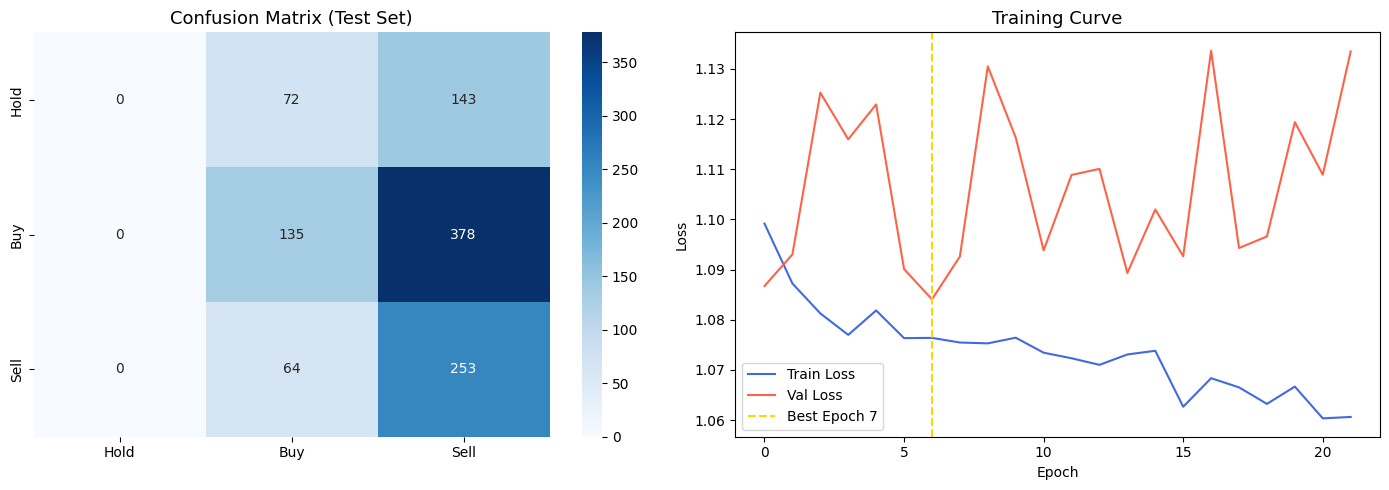

✅ LSTM test probabilities saved for DQN input.


In [5]:
# ---- Load best checkpoint ----
ckpt = torch.load(MODEL_DIR / 'best_lstm.pth', map_location=device)
model.load_state_dict(ckpt['model_state'])
model.eval()

all_preds, all_probs, all_labels = [], [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        logits  = model(X_batch)
        probs   = torch.softmax(logits, dim=1).cpu().numpy()
        preds   = logits.argmax(dim=1).cpu().numpy()
        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

all_probs  = np.array(all_probs)
all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

print('📊 Test Set Classification Report')
print('=' * 50)
print(classification_report(all_labels, all_preds,
                             target_names=['Hold', 'Buy', 'Sell']))

# ---- Confusion Matrix ----
cm = confusion_matrix(all_labels, all_preds)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Hold','Buy','Sell'], yticklabels=['Hold','Buy','Sell'])
axes[0].set_title('Confusion Matrix (Test Set)', fontsize=13)

axes[1].plot(train_losses, label='Train Loss', color='royalblue')
axes[1].plot(val_losses,   label='Val Loss',   color='tomato')
axes[1].axvline(best_epoch - 1, ls='--', color='gold', label=f'Best Epoch {best_epoch}')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].set_title('Training Curve', fontsize=13)
axes[1].legend()
plt.tight_layout()
plt.savefig(BASE_DIR / 'results' / 'metrics' / 'lstm_training.png', dpi=120)
plt.show()

# ---- Save predictions for DQN input ----
import pickle
with open(DATA_PROC / 'lstm_test_probs.pkl', 'wb') as f:
    pickle.dump({'probs': all_probs, 'preds': all_preds, 'labels': all_labels}, f)
print('✅ LSTM test probabilities saved for DQN input.')